# LSTM Code From DL

In [2]:
import numpy as np
import pandas as pd
import os
import torch
import torch.nn as nn
#import torch.optim as optim

In [8]:
class LSTM(nn.Module):
  def __init__(self, input_size, hidden_size, device):
    super(LSTM, self).__init__()
    self.device = device
    self.params = nn.ParameterList(self.init_params(input_size, hidden_size))
    """
    Inputs:
      input_size: int, feature dimension of input sequence
      hidden_size: int, feature dimension of hidden state
      device: torch.device()
    """

  def init_params(self, input_size, hidden_size):
    """
    Inputs:
      input_size: int, feature dimension of input sequence
      hidden_size: int, feature dimension of hidden state

    Outputs:
      Weights for proposal: W_xc, W_hc, b_c
      Weights for input gate: W_xi, W_hi, b_i
      Weights for forget gate: W_xf, W_hf, b_f
      Weights for output gate: W_xo, W_ho, b_o
    """

    W_xc, W_hc, b_c = torch.randn(input_size, hidden_size) * 0.1, torch.randn(hidden_size, hidden_size) * 0.1, torch.zeros(hidden_size)
    W_xi, W_hi, b_i = torch.randn(input_size, hidden_size) * 0.1, torch.randn(hidden_size, hidden_size) * 0.1, torch.zeros(hidden_size)
    W_xf, W_hf, b_f = torch.randn(input_size, hidden_size) * 0.1, torch.randn(hidden_size, hidden_size) * 0.1, torch.zeros(hidden_size)
    W_xo, W_ho, b_o = torch.randn(input_size, hidden_size) * 0.1, torch.randn(hidden_size, hidden_size) * 0.1, torch.zeros(hidden_size)

    params = [W_xc, W_hc, b_c, W_xi, W_hi, b_i, W_xf, W_hf, b_f, W_xo, W_ho, b_o]
    return params


  def lstm(self, X, state):
    """
    Inputs:
      X: tuple of tensors (src, src_len). src, size (N, D_in) or (N, T, D_in), where N is the batch size,
        T is the length of the sequence(s). src_len, size of (N,), is the valid length for each sequence.

      state: tuple of tensors (h, c). h, size of (N, hidden_size) is the hidden state of LSTM. c, size of
            (N, hidden_size), is the memory cell of the LSTM.

    Outputs:
      o: tensor of size (N, T, hidden_size). Contains the output features (the hidden state H_t) for each t.
      state: the same as input state. Contains the hidden state H_T and cell state C_T for the last timestep T.
    """

    src, src_len = X
    h, c = state

    # make sure always has a T dim
    if len(src.shape) == 2:
      src = src.unsqueeze(1)

    N, T, D_in = src.shape
    W_xc, W_hc, b_c, W_xi, W_hi, b_i, W_xf, W_hf, b_f, W_xo, W_ho, b_o = self.params
    o = []

    #have to iterate through the sequences in parallel word by word (T)
    for t in range(T):
      x_t = src[:, t, :] #get the t^{th} input

      i_t = torch.sigmoid(x_t @ W_xi + h @ W_hi + b_i) #input gate
      f_t = torch.sigmoid(x_t @ W_xf + h @ W_hf + b_f) #forget gate
      o_t = torch.sigmoid(x_t @ W_xo + h @ W_ho + b_o) #output gate
      c_t = torch.tanh(x_t @ W_xc + h @ W_hc + b_c) #proposal

      c = f_t * c + i_t * c_t #state update
      h = o_t * torch.tanh(c_t) #hidden update

      o.append(h.unsqueeze(1))
    o = torch.cat(o, dim=1)
    state = (h, c)
    return o, state

  def forward(self, inputs, state):
    return self.lstm(inputs, state)

In [4]:
test_lstm = LSTM(10, 5, torch.device('cpu'))
test_src = torch.ones(12, 8, 10)
test_src_len = torch.ones(12) * 8
test_h = torch.zeros(12, 5).float()
test_c = torch.zeros(12, 5).float()

test_o, test_state = test_lstm((test_src, test_src_len), (test_h, test_c))

print(test_o.shape)
print(test_state[0].shape)
print(test_state[1].shape)

torch.Size([12, 8, 5])
torch.Size([12, 5])
torch.Size([12, 5])


In [5]:
def masked_softmax(X, valid_length):
  """
  inputs:
    X: 3-D tensor
    valid_length: 1-D or 2-D tensor
  """
  mask_value = -1e7

  if len(X.shape) == 2:
    X = X.unsqueeze(1)

  N, n, m = X.shape

  if len(valid_length.shape) == 1:
    valid_length = valid_length.repeat_interleave(n, dim=0)
  else:
    valid_length = valid_length.reshape((-1,))

  mask = torch.arange(m)[None, :].to(X.device) >= valid_length[:, None]
  X.view(-1, m)[mask] = mask_value

  Y = torch.softmax(X, dim=-1)


  return Y

In [9]:
class DotProductAttention(nn.Module):
  def __init__(self):
      super(DotProductAttention, self).__init__()

  def forward(self, query, key, value, valid_length=None):
    """
    inputs:
      query: tensor of size (B, n, d)
      key: tensor of size (B, m, d)
      value: tensor of size (B, m, dim_v)
      valid_length: (B, )

      B is the batch_size, n is the number of queries, m is the number of <key, value> pairs,
      d is the feature dimension of the query, and dim_v is the feature dimension of the value.

    Outputs:
      attention: tensor of size (B, n, dim_v), weighted sum of values
    """
    temp = torch.bmm(query, key.transpose(1,2)) / torch.sqrt(torch.tensor(query.size(-1)))
    temp_soft = masked_softmax(temp, valid_length)
    attention = torch.bmm(temp_soft, value)

    return attention

In [10]:
class MLPAttention(nn.Module):
  def __init__(self, d_v, d_k, d_q):
    super(MLPAttention, self).__init__()
    """
    Inputs:
      d_k: feature dimension of key
      d_v: feature dimension of vector v
      d_q: feature dimension of query
    """

    self.W_k = nn.Linear(d_k, d_v)
    self.W_q = nn.Linear(d_q, d_v)
    self.v = nn.Linear(d_v, 1)

  def forward(self, query, key, value, valid_length):
    """
    inputs:
      query: tensor of size (B, n, d)
      key: tensor of size (B, m, d)
      value: tensor of size (B, m, dim_v)
      valid_length: either (B, )

      B is the batch_size, n is the number of queries, m is the number of <key, value> pairs,
      d is the feature dimension of the query, and dim_v is the feature dimension of the value.

    Outputs:
      attention: tensor of size (B, n, dim_v), weighted sum of values
    """

    q_proj = self.W_q(query)
    k_proj = self.W_k(key)
    weights = torch.tanh(q_proj.unsqueeze(2) + k_proj.unsqueeze(1))
    Y = self.v(weights)
    Y = masked_softmax(Y.squeeze(3), valid_length)
    Y = torch.bmm(Y, values)

    return Y

# LSTM from PyTorch

## Train/Test Split

Want to use the first 30 years to train/eval and the last 8 years to test

In [58]:
import torch
import torch.nn as nn
import pandas as pd
import numpy as np
from sklearn.model_selection import TimeSeriesSplit
from torch.utils.data import DataLoader, TensorDataset
import os
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import time

path = "/Users/katiebaek/Downloads/Crop-Yield-Prediction/Data/ds-capstone-dataset"
os.chdir(path)

data = pd.read_csv("label_1980_2018_rawyield.csv")

data

,Unnamed: 0,index,id2,year,yield
0,0,1,112,1980,27.0
1,1,2,113,1980,28.0
2,2,3,119,1980,29.0
3,3,4,120,1980,28.0
4,4,5,124,1980,24.0
...,...,...,...,...,...
45333,874,54751,3121,2018,182.0
45334,875,54752,3122,2018,156.8
45335,876,54753,3123,2018,163.4
45336,877,54754,3124,2018,160.4


In [45]:
def build_base_arrays(feature_paths, yield_path,
                      county_col="id2", year_col="year", yield_col="yield"):
    """
    Assumes:
      - yield CSV has columns: county, year, yield
      - each feature CSV has columns: county, year, and 210 daily columns already in correct order
      - rows align by (county, year) after a simple merge
    Returns:
      X: (N, 210, F)
      y: (N,)
      years: (N,)
      feature_names: list of str (from file names)
    """
    ydf = pd.read_csv(yield_path)
    index_df = ydf[[county_col, year_col]].copy()
    y = ydf[yield_col].to_numpy()
    years = ydf[year_col].to_numpy()

    feat_arrays = []
    feature_names = []

    for p in feature_paths:
        f = np.load(p, allow_pickle=True)
        feat_arrays.append(f[..., None])       # (N, 210, 1)
        feature_names.append(p[2:-19])
        
    X = np.concatenate(feat_arrays, axis=2)
    #ids = list(zip(index_df[county_col], index_df[year_col]))
    return X, y, years, feature_names

def build_train_test_datasets(X, y, years, test_years = [2016, 2017, 2018]):
    test_indices = np.where(np.isin(years, test_years))[0]
    train_indices = np.where(~np.isin(years, test_years))[0]
    X_test = X[test_indices, :, :]
    y_test = y[test_indices]
    X_train = X[train_indices, :, :]
    y_train = y[train_indices]
    years_train = years[train_indices]
    years_test = years[test_indices]
    return X_train, X_test, y_train, y_test, years_train, years_test




In [36]:
X.shape

(45338, 210, 10)

In [44]:
def fit_scaler_per_feature(X_train): 
    flat = X_train.reshape(-1, X_train.shape[-1])  
    mean = flat.mean(axis=0)
    std  = flat.std(axis=0) + 1e-8
    return mean, std

def apply_scaler_per_feature(X, mean, std):
    return (X - mean) / std


In [43]:
class LSTMRegressor(nn.Module):
    def __init__(self, in_features, hidden=128, layers=1, dropout=0.0):
        super().__init__()
        self.lstm = nn.LSTM(
            input_size=in_features,
            hidden_size=hidden,
            num_layers=layers,
            batch_first=True,
            dropout=dropout if layers > 1 else 0.0,
        )
        self.head = nn.Linear(hidden, 1)

    def forward(self, x):               # x: (B, T, F)
        out, _ = self.lstm(x)           # (B, T, H)
        last = out[:, -1, :]            # (B, H)
        return self.head(last).squeeze(-1)  # (B,)

In [62]:
def train_eval_fold(X, y, years, holdout_year,
                    batch_size=32, epochs=100, lr=1e-3,
                    hidden=128, layers=1, dropout=0.0, device=None):
    device = device or ("cuda" if torch.cuda.is_available() else "cpu")

    # split
    train_idx = np.where(years < holdout_year)[0]
    val_idx   = np.where(years == holdout_year)[0]
    Xtr, ytr = X[train_idx], y[train_idx]
    Xva, yva = X[val_idx], y[val_idx]

    # scale on train only
    mean, std = fit_scaler_per_feature(Xtr)
    Xtr = apply_scaler_per_feature(Xtr, mean, std)
    Xva = apply_scaler_per_feature(Xva, mean, std)

    # tensors + loaders
    ds_tr = TensorDataset(torch.from_numpy(Xtr).float(), torch.from_numpy(ytr).float())
    ds_va = TensorDataset(torch.from_numpy(Xva).float(), torch.from_numpy(yva).float())
    dl_tr = DataLoader(ds_tr, batch_size=batch_size, shuffle=True)
    dl_va = DataLoader(ds_va, batch_size=batch_size, shuffle=False)
    print("loaded data")

    # model/opt/loss
    model = LSTMRegressor(in_features=X.shape[-1], hidden=hidden, layers=layers, dropout=dropout).to(device)
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    lossf = nn.MSELoss()

    # save mse within epochs
    mse_epochs, mse_values = [], []

    # train
    for epoch in range(epochs):
        if epoch % 10 == 0:
            print(f"training epoch number {epoch}")
        model.train()
        running_loss, seen = 0, 0
        for xb, yb in dl_tr:
            xb = xb.to(device)
            yb = yb.to(device)
            pred = model(xb)
            loss = lossf(pred, yb)
            opt.zero_grad()
            loss.backward()
            #torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)  # optional
            opt.step()
            running_loss += loss.item() * xb.size(0)  
            seen += xb.size(0)  
        if (epoch + 1) % 10 == 0:                   
            epoch_mse = running_loss / max(seen, 1)
            mse_epochs.append(epoch + 1)
            mse_values.append(epoch_mse)
    # plot values
    if mse_values:                                 
        plt.figure()
        plt.plot(mse_epochs, mse_values, marker='o')
        plt.xlabel('Epoch')
        plt.ylabel('Train MSE')
        plt.title(f'Train MSE (every 10 epochs) — holdout {holdout_year}')
        plt.grid(True, alpha=0.3)
        plt.savefig(f'Train MSE (every 10 epochs) — holdout {holdout_year}')
        plt.show()

    # eval on held-out year
    model.eval()
    preds = []
    with torch.no_grad():
        for xb, _ in dl_va:
            xb = xb.to(device)
            preds.append(model(xb).cpu().numpy())
    yhat = np.concatenate(preds, axis=0)
    mae  = float(np.mean(np.abs(yhat - yva)))
    rmse = float(np.sqrt(np.mean((yhat - yva) ** 2)))

    return {"year": int(holdout_year), "rmse": rmse, "mae": mae, "n_val": int(len(yva))}, yhat

# -------------------------
# full LOYO CV driver
# -------------------------
def loyo_cv(X, y, years, y_hold_start,
            batch_size=32, epochs=100, lr=1e-3,
            hidden=128, layers=1, dropout=0.0):
    results = []
    per_year_preds = {}  # optional: keep predictions per held-out year
    for y_hold in range(y_hold_start, y_hold_start+1):
        start_time = time.perf_counter()
        metrics, yhat = train_eval_fold(
            X, y, years, holdout_year=y_hold,
            batch_size=batch_size, epochs=epochs, lr=lr,
            hidden=hidden, layers=layers, dropout=dropout
        )
        end_time = time.perf_counter()
        elapsed_time = end_time - start_time
        print(f"time to fold fold for y_hold: {elapsed_time}")
        results.append(metrics)
        per_year_preds[y_hold] = yhat
        print(f"Year {y_hold}: RMSE {metrics['rmse']:.3f} | MAE {metrics['mae']:.3f} | n={metrics['n_val']}")

    # summarize
    rmses = [r["rmse"] for r in results]
    maes  = [r["mae"]  for r in results]
    print(f"\nLOYO mean RMSE: {np.mean(rmses):.3f} (std {np.std(rmses):.3f})")
    print(f"LOYO mean  MAE: {np.mean(maes):.3f} (std {np.std(maes):.3f})")
    return results, per_year_preds

In [47]:
feature_paths = [x for x in os.listdir() if x != 'label_1980_2018_rawyield.csv']
yield_path = 'label_1980_2018_rawyield.csv'

X, y, years, feature_names = build_base_arrays(feature_paths, yield_path)

X_train, X_test, y_train, y_test, years_train, years_test = build_train_test_datasets(X, y, years)


loaded data
training epoch number 0
training epoch number 1
training epoch number 2
training epoch number 3
training epoch number 4
training epoch number 5
training epoch number 6
training epoch number 7
training epoch number 8
training epoch number 9
training epoch number 10
training epoch number 11
training epoch number 12
training epoch number 13
training epoch number 14
training epoch number 15
training epoch number 16
training epoch number 17
training epoch number 18
training epoch number 19
training epoch number 20
training epoch number 21
training epoch number 22
training epoch number 23
training epoch number 24
training epoch number 25
training epoch number 26
training epoch number 27
training epoch number 28
training epoch number 29
training epoch number 30
training epoch number 31
training epoch number 32
training epoch number 33
training epoch number 34
training epoch number 35
training epoch number 36
training epoch number 37
training epoch number 38
training epoch number 3

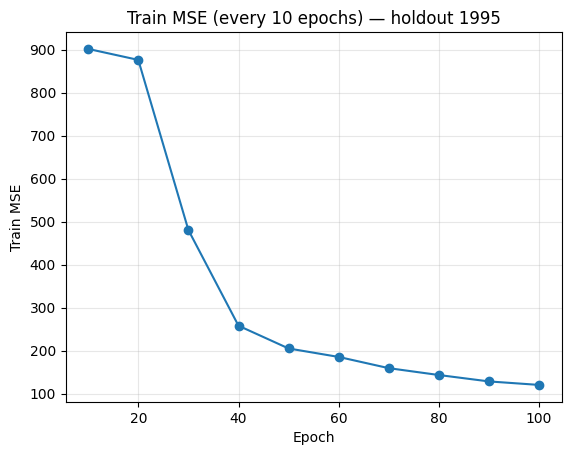

time to fold fold for y_hold: 2214.5947949999245
Year 1995: RMSE 24.569 | MAE 19.022 | n=1199

LOYO mean RMSE: 24.569 (std 0.000)
LOYO mean  MAE: 19.022 (std 0.000)


In [64]:
results, per_year_preds = loyo_cv(X_train, y_train, years_train, 1995)

In [26]:


# train-test split for time series
train_size = int(len(timeseries) * 0.67)
test_size = len(timeseries) - train_size
train, test = timeseries[:train_size], timeseries[train_size:]

def create_dataset(dataset, lookback):
    """Transform a time series into a prediction dataset
    
    Args:
        dataset: A numpy array of time series, first dimension is the time steps
        lookback: Size of window for prediction
    """
    X, y = [], []
    for i in range(len(dataset)-lookback):
        feature = dataset[i:i+lookback]
        target = dataset[i+1:i+lookback+1]
        X.append(feature)
        y.append(target)
    return torch.tensor(X), torch.tensor(y)

lookback = 4
X_train, y_train = create_dataset(train, lookback=lookback)
X_test, y_test = create_dataset(test, lookback=lookback)

class AirModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.lstm = nn.LSTM(input_size=1, hidden_size=50, num_layers=1, batch_first=True)
        self.linear = nn.Linear(50, 1)
    def forward(self, x):
        x, _ = self.lstm(x)
        x = self.linear(x)
        return x

model = AirModel()
optimizer = optim.Adam(model.parameters())
loss_fn = nn.MSELoss()
loader = data.DataLoader(data.TensorDataset(X_train, y_train), shuffle=True, batch_size=8)

n_epochs = 2000
for epoch in range(n_epochs):
    model.train()
    for X_batch, y_batch in loader:
        y_pred = model(X_batch)
        loss = loss_fn(y_pred, y_batch)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
    # Validation
    if epoch % 100 != 0:
        continue
    model.eval()
    with torch.no_grad():
        y_pred = model(X_train)
        train_rmse = np.sqrt(loss_fn(y_pred, y_train))
        y_pred = model(X_test)
        test_rmse = np.sqrt(loss_fn(y_pred, y_test))
    print("Epoch %d: train RMSE %.4f, test RMSE %.4f" % (epoch, train_rmse, test_rmse))

with torch.no_grad():
    # shift train predictions for plotting
    train_plot = np.ones_like(timeseries) * np.nan
    y_pred = model(X_train)
    y_pred = y_pred[:, -1, :]
    train_plot[lookback:train_size] = model(X_train)[:, -1, :]
    # shift test predictions for plotting
    test_plot = np.ones_like(timeseries) * np.nan
    test_plot[train_size+lookback:len(timeseries)] = model(X_test)[:, -1, :]
# plot
plt.plot(timeseries)
plt.plot(train_plot, c='r')
plt.plot(test_plot, c='g')
plt.show()

ValueError: all input arrays must have the same shape